# 02 Modelltraining

Ziel: Logistic Regression, Random Forest, HistGradientBoosting und optional MLPClassifier vergleichen. Bewertet wird mit Accuracy, Macro-F1 und Konfusionsmatrix.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [5]:
dry_bean = fetch_ucirepo(id=602)
X_all = dry_bean.data.features
y = dry_bean.data.targets.squeeze()

selected_features = [
    "Area",
    "AspectRatio",
    "Eccentricity",
    "Compactness",
    "Roundness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor4",
]
X = X_all[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((10888, 8), (2723, 8))

## Modelle

Skalierung wird fuer Logistic Regression und MLP verwendet. Baumverfahren benoetigen sie nicht zwingend.

In [27]:
# Hyperparameter Tuning for MLP Classifier
param_grid = {
    'model__hidden_layer_sizes': [(50,), (60,60), (50, 50), (100, 50), (64, 32), (40,40)],
    'model__activation': ['relu', 'tanh'],
    'model__solver': ['adam', 'sgd'],
    'model__alpha': [0.04, 0.05, 0.06],
    'model__learning_rate': ['constant', 'adaptive'],
}

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(max_iter=300, random_state=RANDOM_STATE, early_stopping=False, n_iter_no_change=5)),
])

grid_search = GridSearchCV(mlp_pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters for MLP:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Update the MLP model with best parameters
best_mlp = grid_search.best_estimator_

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best parameters for MLP: {'model__activation': 'tanh', 'model__alpha': 0.05, 'model__hidden_layer_sizes': (60, 60), 'model__learning_rate': 'constant', 'model__solver': 'adam'}
Best cross-validation score: 0.9416390753708592


In [28]:
mlp_model = best_mlp if 'best_mlp' in globals() else Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True, # War vorher auf True, hat aber das Ergebnis verschlechtert
    )),
])

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=30, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP Neural Network": mlp_model,
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[name] = model
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
results_df

,model,accuracy,macro_f1
3,MLP Neural Network,0.923614,0.934729
1,Random Forest,0.919207,0.931589
0,Logistic Regression,0.917003,0.930761
2,Hist Gradient Boosting,0.915534,0.927294


In [20]:
best_model_name = results_df.iloc[0]["model"]

for model in results_df["model"]:
    print(model)
    print(classification_report(y_test, y_pred))

best_model = fitted_models[best_model_name]
y_pred = best_model.predict(X_test)

print(best_model_name)
print(classification_report(y_test, y_pred))

MLP Neural Network
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.91      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.92      0.93       326
    DERMASON       0.90      0.94      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.96      0.95       406
        SIRA       0.88      0.85      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723

Random Forest
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.91      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.92      0.93       326
    DERMASON       0.90      0.94      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.96      0.95  

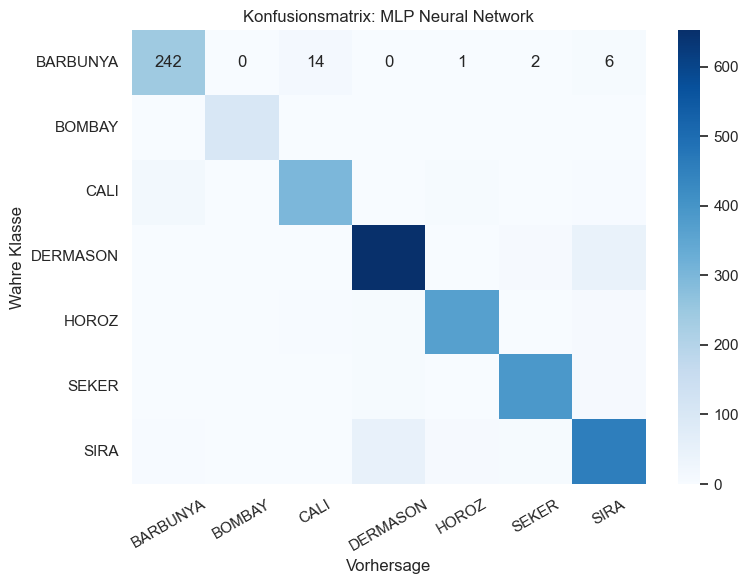

In [8]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Konfusionsmatrix: {best_model_name}")
plt.xlabel("Vorhersage")
plt.ylabel("Wahre Klasse")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()